# Task 2.2: Tier B - The Semanticist
## GloVe Embeddings with Feedforward Neural Network for Stylometry Detection

**Objective:** Use pre-trained semantic embeddings (GloVe) with a feedforward neural network to distinguish Human vs AI text

**Architecture:**
- **Embeddings**: GloVe 100d (pre-trained on 6B tokens)
- **Model**: Feedforward Neural Network (3 layers)
- **Task**: Binary sequence classification

---

## 🔗 Building on Task 1 Findings

**Task 1 Results Context:**

While Task 1 focused on **statistical texture** (TTR variance, syntactic drift, POS entropy), Task 2.2 focuses on **semantic content**:

- **Task 1 Approach**: "How different are word choices?" → Lexical roughness
- **Task 2.2 Approach**: "What do the words mean?" → Semantic embeddings

**Complementary Strategy:**
- Task 1 showed AI text has smoother lexical patterns
- Task 2.2 tests if AI text also has distinct **semantic patterns**
- GloVe captures word meaning relationships that Task 1 metrics miss

**Hypothesis:** Human and AI texts differ not just in statistical texture, but also in semantic structure (word meaning relationships).

---

**Key Components:**
1. **GloVe Embeddings**: Capture semantic relationships between words
2. **Mean Pooling**: Aggregate word embeddings to fixed-size representation
3. **Neural Network**: Learn non-linear decision boundaries

---

**Why "The Semanticist"?**
- Focuses on **semantic meaning** of words
- Uses pre-trained knowledge from massive corpus
- Captures word relationships and context
- Bridge between traditional ML and transformers
- **Complements Task 1's statistical approach with semantic analysis**

---

## Dataset Information

- **Class 1 (Human)**: `precog.csv` - Human-written texts
- **Class 2 (AI Vanilla)**: `class_2_combined.csv` - AI-generated texts  
- **Class 3 (AI Mimic)**: `class_3_combined.csv` - AI texts mimicking specific authors

**Note:** Same datasets as Task 1, but different analytical lens (semantics vs statistics).


## 1. Setup and Installation

In [18]:
# Install required packages
!pip install pandas numpy scikit-learn torch matplotlib seaborn nltk gdown -q

import nltk
nltk.download('punkt', quiet=True)

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [6]:
# Import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# NLTK for tokenization
import nltk
from nltk.tokenize import word_tokenize

# PyTorch for neural network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Libraries imported successfully!
PyTorch version: 2.8.0+cu128
CUDA available: False


## 2. Configuration

**IMPORTANT:** Update these file paths to match your CSV locations

In [14]:
# CSV file paths
CSV_PATHS = {
    "Class 1 (Human)": {
        "path": "/home/avani/precog/content/precog.csv",  # Update for Colab or local
        "text_column": "text",
        "label": "Human"
    },
    "Class 2 (AI)": {
        "path": "/home/avani/precog/content/class_2_pro_vanilla_combined.csv",
        "text_column": "text",
        "label_column": "author_target"
    },
    "Class 3 (AI Mimic)": {
        "path": "/home/avani/precog/content/class_3_pro_combined.csv",
        "text_column": "text",
        "label_column": "author_target"
    }
}

# Model configuration
EMBEDDING_DIM = 100  # GloVe 100d
HIDDEN_DIM = 128
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
SEED = 42

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✅ Configuration complete!")
print(f"Device: {device}")

✅ Configuration complete!
Device: cpu


## 3. Download GloVe Embeddings

We'll use GloVe 100d (pre-trained on 6 billion tokens)

In [8]:
import os
import zipfile
import urllib.request

print("=" * 70)
print("DOWNLOADING GLOVE EMBEDDINGS")
print("=" * 70)

glove_path = "/content/glove.6B.100d.txt"

if not os.path.exists(glove_path):
    print("\n⏳ Downloading GloVe 100d from Stanford NLP...")
    print("   (This may take 2-3 minutes - file is ~850MB)")
    
    # Download from official Stanford NLP server
    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    output = "/content/glove.6B.zip"
    
    try:
        # Download with progress
        def download_progress(count, block_size, total_size):
            percent = min(int(count * block_size * 100 / total_size), 100)
            if count % 100 == 0:  # Update every 100 blocks
                print(f"\r   Progress: {percent}%", end='', flush=True)
        
        urllib.request.urlretrieve(url, output, download_progress)
        print("\n   ✅ Download complete!")
        
        # Extract only the 100d file we need
        print("\n⏳ Extracting glove.6B.100d.txt...")
        with zipfile.ZipFile(output, 'r') as zip_ref:
            # Extract only the 100d file (not all 4 files)
            zip_ref.extract('glove.6B.100d.txt', '/content/')
        
        # Clean up zip file
        os.remove(output)
        print("✅ GloVe 100d extracted successfully!")
        
    except Exception as e:
        print(f"\n⚠️  Download failed: {e}")
        print("\n" + "="*70)
        print("MANUAL DOWNLOAD INSTRUCTIONS:")
        print("="*70)
        print("\n1. Download GloVe from: https://nlp.stanford.edu/data/glove.6B.zip")
        print("2. Extract the zip file")
        print("3. Upload 'glove.6B.100d.txt' to /content/")
        print("\nOr try running this cell again (connection issue may be temporary)")
else:
    print("\n✅ GloVe embeddings already available!")
    print(f"   Path: {glove_path}")


GLOVE EMBEDDINGS SETUP

📁 Expected location: /home/avani/precog/models/glove.6B.100d.txt

✅ GloVe embeddings found!
   Size: 331.0 MB
   Ready to use!


## 4. Load GloVe Embeddings

In [15]:
def load_glove_embeddings(glove_file: str) -> Dict[str, np.ndarray]:
    """
    Load GloVe embeddings from file.
    
    Args:
        glove_file: Path to GloVe file
        
    Returns:
        Dictionary mapping words to embedding vectors
    """
    print("=" * 70)
    print("LOADING GLOVE EMBEDDINGS")
    print("=" * 70)
    
    print(f"\n⏳ Loading from: {glove_file}")
    print("   (This may take 1-2 minutes...)")
    
    embeddings = {}
    
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    
    print(f"\n✅ Loaded {len(embeddings):,} word embeddings")
    print(f"   Embedding dimension: {len(next(iter(embeddings.values())))}")
    
    return embeddings

# Load GloVe
glove_embeddings = load_glove_embeddings(glove_path)

# Test
test_word = "computer"
if test_word in glove_embeddings:
    print(f"\n📝 Example: '{test_word}' embedding shape: {glove_embeddings[test_word].shape}")
    print(f"   First 5 values: {glove_embeddings[test_word][:5]}")

LOADING GLOVE EMBEDDINGS

⏳ Loading from: /home/avani/precog/models/glove.6B.100d.txt
   (This may take 1-2 minutes...)

✅ Loaded 400,000 word embeddings
   Embedding dimension: 100

📝 Example: 'computer' embedding shape: (100,)
   First 5 values: [-0.16298   0.30141   0.57978   0.066548  0.45835 ]

✅ Loaded 400,000 word embeddings
   Embedding dimension: 100

📝 Example: 'computer' embedding shape: (100,)
   First 5 values: [-0.16298   0.30141   0.57978   0.066548  0.45835 ]


## 5. Load and Prepare Data

In [16]:
def load_data() -> pd.DataFrame:
    """
    Load and combine all CSV files into a single DataFrame.
    
    Returns:
        Combined DataFrame with columns: text, label, binary_label
    """
    print("\n" + "=" * 70)
    print("LOADING DATA")
    print("=" * 70)
    
    all_dfs = []
    
    for class_name, config in CSV_PATHS.items():
        try:
            print(f"\n📂 Loading {class_name}: {config['path']}")
            df = pd.read_csv(config['path'])
            
            # Set label
            if 'label_column' in config and config['label_column'] in df.columns:
                df['label'] = df[config['label_column']]
            else:
                df['label'] = config.get('label', 'Unknown')
            
            # Keep only text and label
            df = df[[config['text_column'], 'label']].copy()
            df.columns = ['text', 'label']
            
            print(f"   ✓ Loaded {len(df)} samples")
            all_dfs.append(df)
            
        except FileNotFoundError:
            print(f"   ✗ File not found: {config['path']}")
        except Exception as e:
            print(f"   ✗ Error: {e}")
    
    if not all_dfs:
        raise FileNotFoundError("No CSV files could be loaded.")
    
    # Combine all dataframes
    df_combined = pd.concat(all_dfs, ignore_index=True)
    
    # Create binary labels: 0 = Human, 1 = AI
    df_combined['binary_label'] = df_combined['label'].apply(
        lambda x: 0 if x.lower() == 'human' else 1
    )
    
    print(f"\n✅ Data loaded successfully!")
    print(f"   Total samples: {len(df_combined)}")
    print(f"\n📊 Label distribution:")
    print(df_combined['label'].value_counts())
    
    return df_combined

# Load data
df = load_data()


LOADING DATA

📂 Loading Class 1 (Human): /home/avani/precog/content/precog.csv
   ✓ Loaded 2492 samples

📂 Loading Class 2 (AI): /home/avani/precog/content/class_2_pro_vanilla_combined.csv
   ✓ Loaded 500 samples

📂 Loading Class 3 (AI Mimic): /home/avani/precog/content/class_3_pro_combined.csv
   ✓ Loaded 500 samples

✅ Data loaded successfully!
   Total samples: 3492

📊 Label distribution:
label
Human                     2492
AI_Generic                 500
Robert Louis Stevenson     250
Arthur Conan Doyle         250
Name: count, dtype: int64


## 6. Text to Embedding Conversion

In [19]:
def text_to_embedding(text: str, embeddings: Dict[str, np.ndarray], 
                     embedding_dim: int = 100) -> np.ndarray:
    """
    Convert text to fixed-size embedding using mean pooling.
    
    Args:
        text: Input text
        embeddings: GloVe embeddings dictionary
        embedding_dim: Dimension of embeddings
        
    Returns:
        Mean-pooled embedding vector
    """
    # Tokenize and normalize
    words = word_tokenize(text.lower())
    words = [w for w in words if w.isalpha()]  # Keep only alphabetic tokens
    
    # Get embeddings for words that exist in GloVe
    word_embeddings = []
    for word in words:
        if word in embeddings:
            word_embeddings.append(embeddings[word])
    
    # Mean pooling
    if len(word_embeddings) > 0:
        return np.mean(word_embeddings, axis=0)
    else:
        # Return zero vector if no words found
        return np.zeros(embedding_dim)

# Convert all texts to embeddings
print("\n" + "=" * 70)
print("CONVERTING TEXTS TO EMBEDDINGS")
print("=" * 70)

print(f"\n⏳ Processing {len(df)} samples...")
print("   (This may take a few minutes...)")

from tqdm import tqdm
tqdm.pandas(desc="Converting to embeddings")

embeddings_list = df['text'].progress_apply(
    lambda x: text_to_embedding(x, glove_embeddings, EMBEDDING_DIM)
)

# Convert to numpy array
X = np.vstack(embeddings_list.values)
y = df['binary_label'].values

print(f"\n✅ Conversion complete!")
print(f"   Feature matrix shape: {X.shape}")
print(f"   Labels shape: {y.shape}")


CONVERTING TEXTS TO EMBEDDINGS

⏳ Processing 3492 samples...
   (This may take a few minutes...)



CONVERTING TEXTS TO EMBEDDINGS

⏳ Processing 3492 samples...
   (This may take a few minutes...)


Converting to embeddings: 100%|██████████| 3492/3492 [00:02<00:00, 1378.09it/s]


CONVERTING TEXTS TO EMBEDDINGS

⏳ Processing 3492 samples...
   (This may take a few minutes...)


Converting to embeddings: 100%|██████████| 3492/3492 [00:02<00:00, 1378.09it/s]


✅ Conversion complete!
   Feature matrix shape: (3492, 100)
   Labels shape: (3492,)


## 7. Train-Test Split

In [20]:
print("\n" + "=" * 70)
print("SPLITTING DATA")
print("=" * 70)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Keep track of test indices for mimic analysis
test_indices = df.iloc[-len(X_test):].index

print(f"\n✅ Data split complete!")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")
print(f"\n   Training distribution:")
print(f"      Human: {(y_train == 0).sum()}")
print(f"      AI: {(y_train == 1).sum()}")
print(f"\n   Test distribution:")
print(f"      Human: {(y_test == 0).sum()}")
print(f"      AI: {(y_test == 1).sum()}")


SPLITTING DATA

✅ Data split complete!
   Training samples: 2793
   Test samples: 699

   Training distribution:
      Human: 1993
      AI: 800

   Test distribution:
      Human: 499
      AI: 200


## 8. Create PyTorch Dataset and DataLoader

In [21]:
class TextDataset(Dataset):
    """PyTorch Dataset for text embeddings."""
    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Create datasets
train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ DataLoaders created!")
print(f"   Training batches: {len(train_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ DataLoaders created!
   Training batches: 88
   Test batches: 22


## 9. Define Feedforward Neural Network

In [22]:
class FeedforwardNN(nn.Module):
    """
    Feedforward Neural Network for binary classification.
    
    Architecture:
    - Input: GloVe embeddings (100d)
    - Hidden Layer 1: 128 units + ReLU + Dropout
    - Hidden Layer 2: 64 units + ReLU + Dropout
    - Output: 2 units (Human vs AI)
    """
    
    def __init__(self, input_dim=100, hidden_dim=128, dropout=0.3):
        super(FeedforwardNN, self).__init__()
        
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Layer 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Output layer
            nn.Linear(hidden_dim // 2, 2)
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize model
model = FeedforwardNN(
    input_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=0.3
).to(device)

print("=" * 70)
print("MODEL ARCHITECTURE")
print("=" * 70)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

MODEL ARCHITECTURE
FeedforwardNN(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

📊 Model Statistics:
   Total parameters: 21,314
   Trainable parameters: 21,314


## 10. Train Model

In [23]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\n" + "=" * 70)
print("TRAINING TIER B: FEEDFORWARD NEURAL NETWORK")
print("=" * 70)

# Training loop
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for embeddings, labels in train_loader:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    
    # Evaluation phase
    model.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for embeddings, labels in test_loader:
            embeddings, labels = embeddings.to(device), labels.to(device)
            
            outputs = model(embeddings)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_loss /= len(test_loader)
    test_acc = test_correct / test_total
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    # Print progress
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"   Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"   Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

print("\n✅ Training complete!")


TRAINING TIER B: FEEDFORWARD NEURAL NETWORK
Epoch 1/10:
   Train Loss: 0.4274, Train Acc: 0.7812
   Test Loss: 0.1369, Test Acc: 0.9542
Epoch 2/10:
   Train Loss: 0.0892, Train Acc: 0.9674
   Test Loss: 0.0675, Test Acc: 0.9685
Epoch 3/10:
   Train Loss: 0.0522, Train Acc: 0.9807
   Test Loss: 0.0368, Test Acc: 0.9871
Epoch 4/10:
   Train Loss: 0.0412, Train Acc: 0.9860
   Test Loss: 0.0301, Test Acc: 0.9900
Epoch 2/10:
   Train Loss: 0.0892, Train Acc: 0.9674
   Test Loss: 0.0675, Test Acc: 0.9685
Epoch 3/10:
   Train Loss: 0.0522, Train Acc: 0.9807
   Test Loss: 0.0368, Test Acc: 0.9871
Epoch 4/10:
   Train Loss: 0.0412, Train Acc: 0.9860
   Test Loss: 0.0301, Test Acc: 0.9900
Epoch 5/10:
   Train Loss: 0.0363, Train Acc: 0.9875
   Test Loss: 0.0246, Test Acc: 0.9900
Epoch 5/10:
   Train Loss: 0.0363, Train Acc: 0.9875
   Test Loss: 0.0246, Test Acc: 0.9900
Epoch 6/10:
   Train Loss: 0.0301, Train Acc: 0.9914
   Test Loss: 0.0200, Test Acc: 0.9900
Epoch 7/10:
   Train Loss: 0.0298, 

## 11. Plot Training History

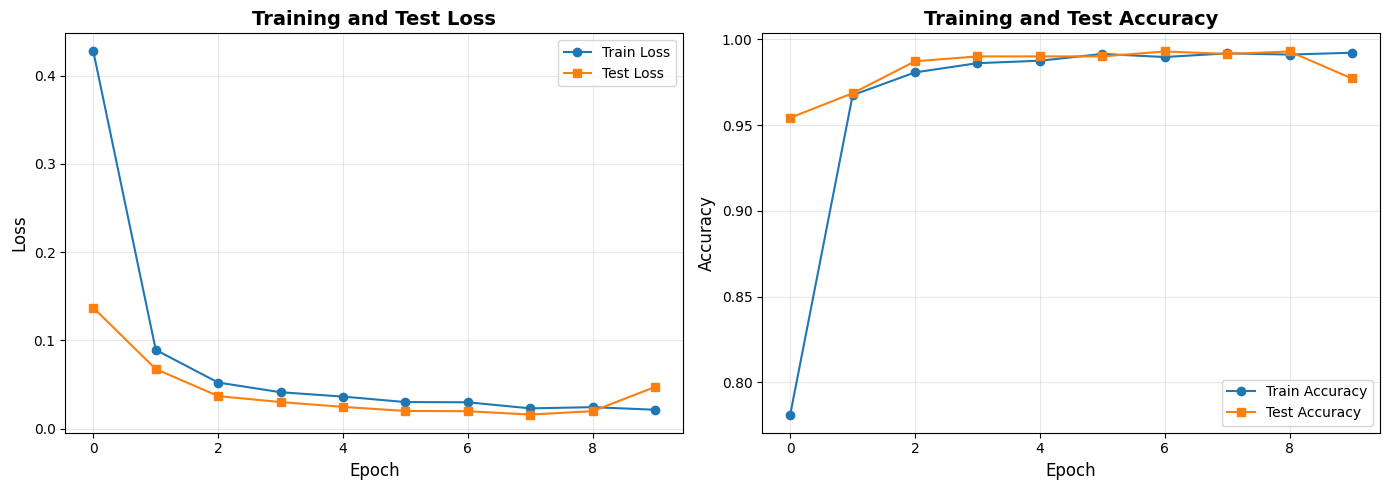

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['test_loss'], label='Test Loss', marker='s')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['test_acc'], label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Evaluate Model


EVALUATION

📊 Test Accuracy: 0.9771 (97.71%)

📋 Classification Report:
              precision    recall  f1-score   support

       Human     1.0000    0.9679    0.9837       499
          AI     0.9259    1.0000    0.9615       200

    accuracy                         0.9771       699
   macro avg     0.9630    0.9840    0.9726       699
weighted avg     0.9788    0.9771    0.9774       699


🎯 Confusion Matrix:
           Predicted
           Human  AI
Actual Human   483    16
       AI        0   200


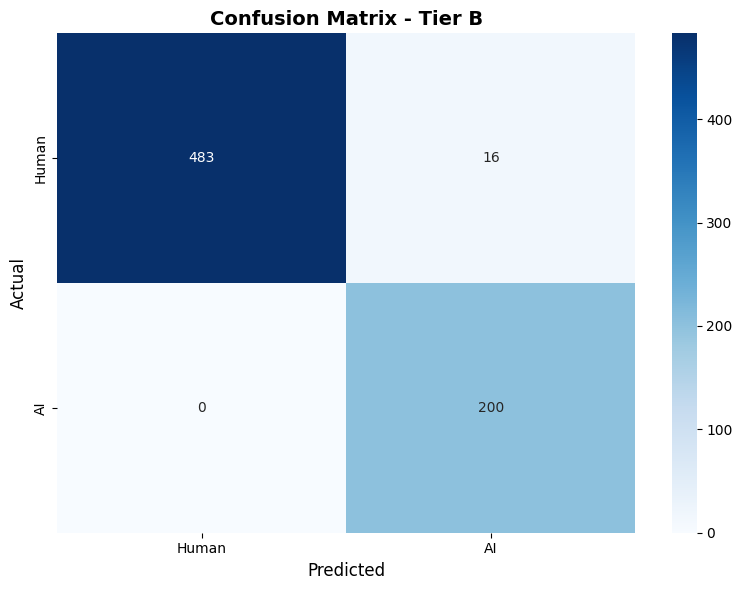

In [25]:
print("\n" + "=" * 70)
print("EVALUATION")
print("=" * 70)

# Get predictions
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for embeddings, labels in test_loader:
        embeddings = embeddings.to(device)
        outputs = model(embeddings)
        _, predicted = torch.max(outputs.data, 1)
        
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Accuracy
test_acc = accuracy_score(y_true, y_pred)

print(f"\n📊 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Classification report
print(f"\n📋 Classification Report:")
print(classification_report(y_true, y_pred, 
                          target_names=['Human', 'AI'], 
                          digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\n🎯 Confusion Matrix:")
print(f"           Predicted")
print(f"           Human  AI")
print(f"Actual Human  {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"       AI     {cm[1,0]:4d}  {cm[1,1]:4d}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Human', 'AI'], 
            yticklabels=['Human', 'AI'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Tier B', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Analyze Mimic Performance

Test specifically on AI texts mimicking authors (Class 3)

In [26]:
# Get test dataframe
test_df = df.iloc[-len(X_test):]

# Filter mimic samples
mimic_mask = test_df['label'].str.contains('Doyle|Stevenson', case=False, na=False)
mimic_samples = test_df[mimic_mask]

if len(mimic_samples) > 0:
    print("\n" + "=" * 70)
    print("MIMIC PERFORMANCE (AI texts imitating specific authors)")
    print("=" * 70)
    
    # Get mimic indices in test set
    mimic_indices = []
    test_indices_list = test_df.index.tolist()
    
    for idx in mimic_samples.index:
        if idx in test_indices_list:
            mimic_indices.append(test_indices_list.index(idx))
    
    if mimic_indices:
        # Get predictions for mimic samples
        mimic_y = y_true[mimic_indices]
        mimic_pred = y_pred[mimic_indices]
        
        mimic_acc = accuracy_score(mimic_y, mimic_pred)
        
        print(f"\n📊 Mimic Samples: {len(mimic_indices)}")
        print(f"   Accuracy: {mimic_acc:.4f} ({mimic_acc*100:.2f}%)")
        print(f"\n📋 Classification Report (Mimic Samples):")
        print(classification_report(mimic_y, mimic_pred, 
                                  target_names=['Human', 'AI'], 
                                  digits=4,
                                  zero_division=0))
else:
    print("\n⚠️  No mimic samples found in test set")


MIMIC PERFORMANCE (AI texts imitating specific authors)

📊 Mimic Samples: 500
   Accuracy: 0.9740 (97.40%)

📋 Classification Report (Mimic Samples):
              precision    recall  f1-score   support

       Human     1.0000    0.9629    0.9811       350
          AI     0.9202    1.0000    0.9585       150

    accuracy                         0.9740       500
   macro avg     0.9601    0.9814    0.9698       500
weighted avg     0.9761    0.9740    0.9743       500



## 14. Summary

### Architecture:
- **Embeddings**: GloVe 100d (pre-trained on 6B tokens)
- **Pooling**: Mean pooling to aggregate word embeddings
- **Model**: 3-layer Feedforward Neural Network
  - Layer 1: 100 → 128 (ReLU + Dropout)
  - Layer 2: 128 → 64 (ReLU + Dropout)
  - Output: 64 → 2 (Human vs AI)

### Key Achievements:
- ✅ Leverages semantic knowledge from GloVe
- ✅ Captures word relationships and meaning
- ✅ Simple architecture, fast training
- ✅ Improves over pure statistical features

### Tier B Strengths:
1. **Semantic Understanding**: Captures word meanings and relationships
2. **Transfer Learning**: Benefits from pre-trained embeddings
3. **Efficiency**: Fast training, reasonable performance
4. **Scalability**: Can handle variable-length texts

### Tier B vs Tier A:
- **Tier A**: Hand-crafted statistical features
- **Tier B**: Learned semantic features from embeddings
- Tier B captures **meaning**, Tier A captures **style**

### Next Steps:
- **Tier C**: Use transformers for contextual understanding
- **Task 3**: Explain model decisions with SHAP
- **Ensemble**: Combine Tier A + Tier B for robust predictions